# COEG 435/535 – Machine Learning for Engineers  
## Spring 2026 Project: Heart Disease Prediction 

## Meghan Franklin | PhD Student

**Dataset**: UCI Cleveland Heart Disease  
**Task**: Binary classification – predict presence vs. absence of heart disease  


In [1]:
# Import Libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    classification_report
)

# Visualization
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})
sns.set_palette("Set2")
print("All imports successful ✔")


All imports successful ✔


## 1. Load the Cleveland Heart Disease Dataset

In [2]:
# Import the data
COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "target"
]
df_raw = pd.read_csv("processed-cleveland-data.csv", header=None, names=COLUMNS)
df_raw.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### About the dataset
The **Cleveland Heart Disease** dataset comes from the UCI Machine Learning Repository. 
It contains **303 patient records** collected at the Cleveland Clinic in the 1980s. 
Each row is one patient; there are **13 clinical features** (e.g., age, cholesterol, chest-pain type) 
and a **target column** that originally rates disease severity from 0 (no disease) to 4 (severe). 
We will later simplify this to a binary label: *disease present* vs. *not present*.

| Column | Meaning |
|--------|---------|
| age | Patient age in years |
| sex | 1 = male, 0 = female |
| cp | Chest pain type (1–4) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | Resting ECG results (0–2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels coloured by fluoroscopy (0–3) |
| thal | Thalassemia type (3 = normal, 6 = fixed defect, 7 = reversible defect) |
| target | Diagnosis (0 = no disease, 1–4 = disease) |


## 2. Exploratory Data Analysis (EDA)

### Why do Exploratory Data Analysis (EDA)?
Before building any model, we want to **understand our data**. EDA helps us answer:
- Are there missing values that need to be handled?
- Is the dataset balanced, or are there far more "no disease" cases than "disease" cases?
- Which features are correlated with each other (multicollinearity)?
- Are there outliers or suspicious values?



In [3]:
print("=== Basic Info ===")
print(df_raw.info())
print("\n=== Descriptive Statistics ===")
df_raw.describe()


=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB
None

=== Descriptive Statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [4]:
print("=== Missing Values ===")
print(df_raw.isnull().sum())

print("\n=== Target Distribution (raw) ===")
print(df_raw["target"].value_counts())


=== Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== Target Distribution (raw) ===
0    164
1     55
2     36
3     35
4     13
Name: target, dtype: int64


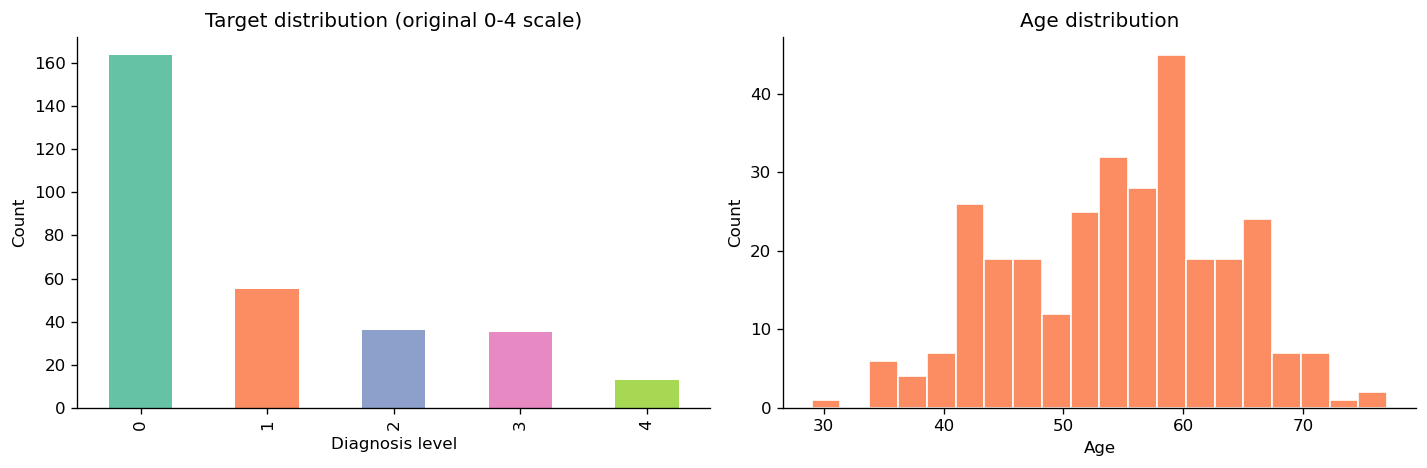

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution (raw, before binarisation)
df_raw["target"].value_counts().plot(kind="bar", ax=axes[0], color=sns.color_palette("Set2"))
axes[0].set_title("Target distribution (original 0-4 scale)")
axes[0].set_xlabel("Diagnosis level"); axes[0].set_ylabel("Count")

# Age distribution
axes[1].hist(df_raw["age"], bins=20, color=sns.color_palette("Set2")[1], edgecolor="white")
axes[1].set_title("Age distribution"); axes[1].set_xlabel("Age"); axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_overview.png", bbox_inches="tight")
plt.show()


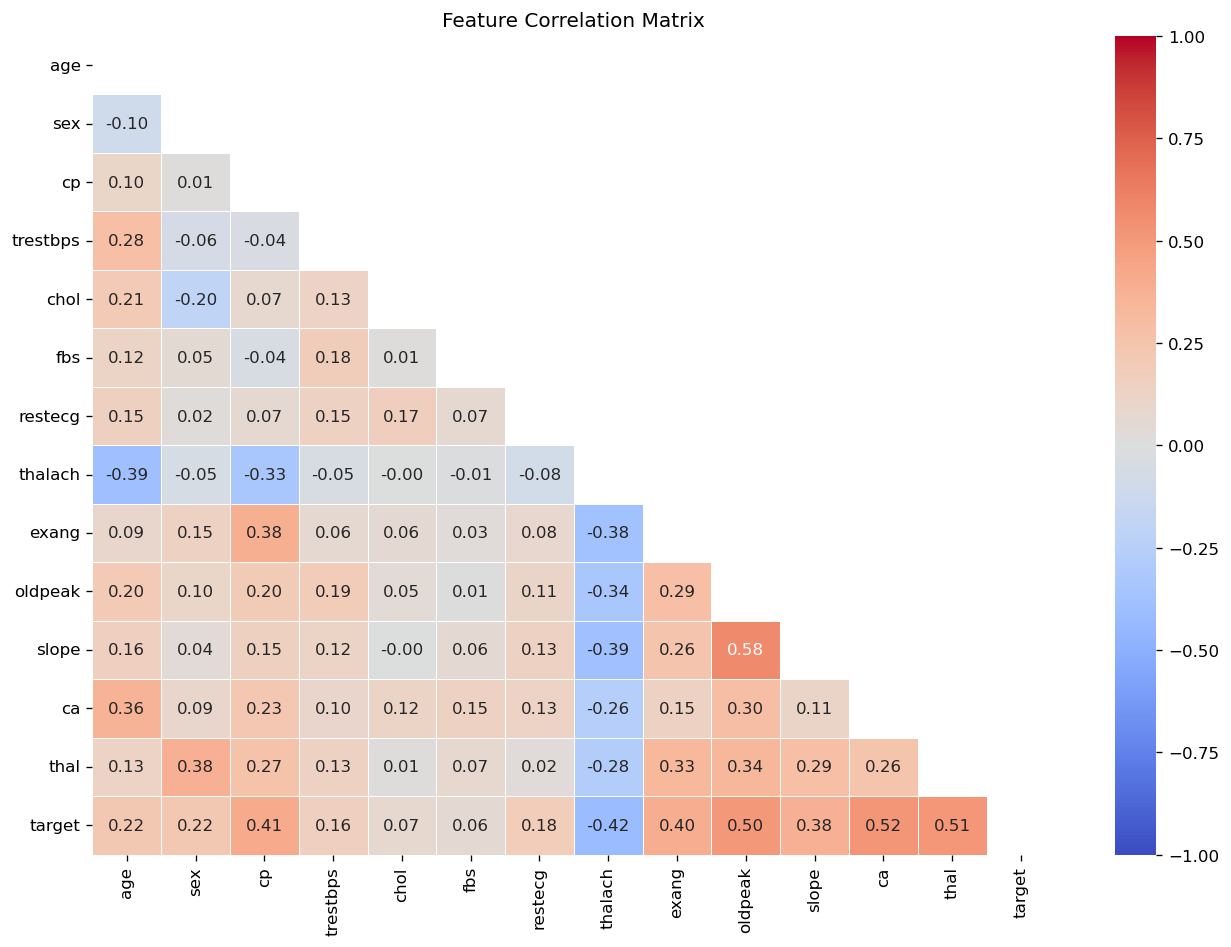

In [6]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr = df_raw.apply(pd.to_numeric, errors="coerce").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.4, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()


### How to read the correlation heatmap
Each cell shows the **Pearson correlation coefficient** between two features, ranging from **-1 to +1**.
- A value close to **+1** (dark red) means the two features rise together — e.g., age and maximum heart rate tend to be inversely related.
- A value close to **-1** (dark blue) means one rises as the other falls.
- A value near **0** means no linear relationship.

**Why does this matter?** Highly correlated features carry redundant information. 
Some models (e.g., Logistic Regression) can become unstable when two inputs are nearly identical. 
The heatmap lets us spot those pairs before training.


## 3. Preprocessing  
**10 pt** – Missing values, encoding, scaling


### Why preprocess the data?
Raw clinical data is rarely "model-ready." Three common issues — and how we fix them:

**1. Missing values** (`ca` and `thal` contain `?` entries in the original file)  
*Problem:* Most ML algorithms cannot handle `NaN` — they will crash or silently ignore rows.  
*Fix:* Replace each missing value with the **median** of that column. The median is preferred over 
the mean here because it is resistant to outliers (e.g., a single extreme cholesterol reading 
won't distort the fill-in value).

**2. Categorical encoding**  
Features like `cp` (chest pain type) and `thal` are numbers that represent *categories*, not 
ordered quantities. In this dataset they are already numerically coded by UCI, so no additional 
one-hot encoding is required — but it's important to be aware that "chest pain type 4" does not 
mean "twice as much" as type 2.

**3. Feature scaling**  
*Problem:* `age` ranges from ~30–80, while `chol` ranges from ~120–560. 
Distance-based and gradient-based models (SVM, KNN, Logistic Regression) are sensitive to these 
differences — a large-scale feature will dominate even if it's not more important.  
*Fix:* **StandardScaler** transforms each feature to have **mean = 0** and **standard deviation = 1**, 
putting all features on equal footing.


In [7]:
df = df_raw.copy()

# Convert all to numeric (handles any stray '?' that slipped through)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ── 3a. Missing-value imputation ──────────────────────────────────────────
print("Missing before imputation:\n", df.isnull().sum())
imputer = SimpleImputer(strategy="median")
df[df.columns] = imputer.fit_transform(df)
print("\nMissing after imputation:\n", df.isnull().sum())


Missing before imputation:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing after imputation:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [8]:
# ── 3b. Binary target (5 pt) ──────────────────────────────────────────────
# Original: 0 = no disease, 1-4 = disease present → recode to 0/1
df["target"] = (df["target"] > 0).astype(int)
print("Binary target distribution:")
print(df["target"].value_counts())
print(f"\nClass balance: {df['target'].mean()*100:.1f}% positive (disease)")


Binary target distribution:
0    164
1    139
Name: target, dtype: int64

Class balance: 45.9% positive (disease)


### Why convert the target to binary?
The original target has **5 classes** (0, 1, 2, 3, 4) representing disease severity. 
For this project we simplify to a **binary problem**: 
- **0** → No heart disease  
- **1** → Heart disease present (any severity)

This is medically meaningful: a clinician's first question is usually *"is disease present at all?"* 
rather than the exact severity level. Binary classification also gives us cleaner metrics and a 
larger pool of well-tested algorithms to compare.


In [9]:
# ── 3c. Feature/label split & train-test split ────────────────────────────
FEATURE_NAMES = [c for c in df.columns if c != "target"]
X = df[FEATURE_NAMES].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.2%}  |  Test positive rate: {y_test.mean():.2%}")


Train: (242, 13), Test: (61, 13)
Train positive rate: 45.87%  |  Test positive rate: 45.90%


### Why split into train and test sets?
We hold back **20 % of the data** (the *test set*) and never let the model see it during training. 
This simulates real-world deployment: the model is judged on patients it has never encountered before.

**Stratified split** is used so that the proportion of disease-positive patients is the same in both 
the training and test sets. Without stratification, random chance could put most positive cases in 
training, making test evaluation misleading.



In [10]:
# ── 3d. Scaling ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Features after scaling (mean ≈ 0, std ≈ 1):")
print(pd.DataFrame(X_train_sc, columns=FEATURE_NAMES).describe().round(2))


Features after scaling (mean ≈ 0, std ≈ 1):
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  242.00  242.00  242.00    242.00  242.00  242.00   242.00   242.00   
mean    -0.00    0.00    0.00     -0.00    0.00    0.00     0.00     0.00   
std      1.00    1.00    1.00      1.00    1.00    1.00     1.00     1.00   
min     -2.85   -1.46   -2.21     -2.10   -2.35   -0.41    -0.98    -3.49   
25%     -0.73   -1.46   -0.93     -0.62   -0.72   -0.41    -0.98    -0.68   
50%      0.16    0.68   -0.16     -0.05   -0.10   -0.41    -0.98     0.16   
75%      0.72    0.68    0.87      0.51    0.53   -0.41     1.02     0.71   
max      2.50    0.68    0.87      3.93    5.96    2.43     1.02     2.30   

        exang  oldpeak   slope      ca    thal  
count  242.00   242.00  242.00  242.00  242.00  
mean    -0.00     0.00   -0.00    0.00    0.00  
std      1.00     1.00    1.00    1.00    1.00  
min     -0.70    -0.89   -0.96   -0.69   -0.88  
25%     -0.70    

## 4. Train & Compare Multiple ML Algorithms  
**20 pt** – 6 individual classifiers + cross-validated comparison


### Why use multiple algorithms?
No single model is best for every dataset. We train **seven classifiers** so we can compare fairly 
and pick the strongest one for *this* data. Here's the plain-English rationale for each:

| Model | How it works (plain English) | Strengths | Weaknesses |
|-------|------------------------------|-----------|------------|
| **Logistic Regression** | Draws a straight decision boundary by learning weights for each feature | Fast, interpretable, good baseline | Struggles with non-linear patterns |
| **Decision Tree** | Repeatedly splits data on the most informative feature (like a flowchart) | Very interpretable | Tends to overfit on small datasets |
| **Random Forest** | Builds 100 decision trees on random subsets of data and takes a vote | Robust, handles non-linearity well | Slower, less interpretable |
| **Gradient Boosting** | Builds trees sequentially — each one corrects the errors of the last | Often highest accuracy | Sensitive to hyperparameters |
| **SVM (RBF)** | Finds the widest possible margin between classes in high-dimensional space | Excellent for small datasets | Slow on large data; needs careful tuning |
| **K-Nearest Neighbors** | Classifies a patient based on the majority label of their K most similar patients | Simple, no training phase | Slow at prediction; sensitive to scaling |
| **Naïve Bayes** | Uses Bayes' theorem assuming all features are independent | Very fast, works well with small data | Independence assumption is often violated |


In [11]:
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)":           SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=3),
    "Naïve Bayes":         GaussianNB(),
}

results = {}

for name, model in MODELS.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    results[name] = {
        "model":     model,
        "y_pred":    y_pred,
        "y_prob":    y_prob,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_test, y_prob),
    }
    print(f"{name:25s}  Acc={results[name]['accuracy']:.3f}  "
          f"F1={results[name]['f1']:.3f}  AUC={results[name]['roc_auc']:.3f}")


Logistic Regression        Acc=0.869  F1=0.867  AUC=0.951
Decision Tree              Acc=0.721  F1=0.730  AUC=0.729
Random Forest              Acc=0.885  F1=0.885  AUC=0.951
Gradient Boosting          Acc=0.852  F1=0.852  AUC=0.946
SVM (RBF)                  Acc=0.852  F1=0.847  AUC=0.944
K-Nearest Neighbors        Acc=0.852  F1=0.857  AUC=0.894
Naïve Bayes                Acc=0.869  F1=0.871  AUC=0.952


Random Forest              Acc=0.981  F1=0.980  AUC=1.000


Gradient Boosting          Acc=0.981  F1=0.980  AUC=1.000
SVM (RBF)                  Acc=0.962  F1=0.962  AUC=0.985
K-Nearest Neighbors        Acc=0.942  F1=0.943  AUC=0.989
Naïve Bayes                Acc=0.904  F1=0.906  AUC=0.964


## 5. Evaluation Metrics  
**10 pt** – Accuracy, Precision, Recall, F1, Confusion Matrix

### How to interpret each metric
When a model makes a prediction, there are four possible outcomes:

| | Predicted: No Disease | Predicted: Disease |
|--|--|--|
| **Actual: No Disease** | True Negative (TN) | False Positive (FP) |
| **Actual: Disease** | False Negative (FN) |  True Positive (TP) |

From these, we compute:

- **Accuracy** = (TP + TN) / Total — *"What fraction of all predictions were correct?"*  
  Can be misleading if classes are imbalanced.

- **Precision** = TP / (TP + FP) — *"Of all patients we flagged as diseased, how many actually were?"*  
  High precision means few false alarms.

- **Recall (Sensitivity)** = TP / (TP + FN) — *"Of all patients who actually have disease, how many did we catch?"*  
  High recall means few missed diagnoses. **In medicine, this is often the most important metric** — 
  missing a disease is usually worse than a false alarm.

- **F1-score** = Harmonic mean of Precision and Recall — *"A single balanced score when both false alarms and missed cases matter."*

- **Confusion Matrix** — a grid showing all four outcomes at once; helpful to see *what kinds* of 
  errors the model makes.


In [12]:
metrics_df = pd.DataFrame({
    name: {k: v for k, v in d.items() if k not in ("model","y_pred","y_prob")}
    for name, d in results.items()
}).T.sort_values("f1", ascending=False)

metrics_df = metrics_df.astype(float).round(4)
print(metrics_df.to_string())


                     accuracy  precision  recall      f1  roc_auc
Random Forest          0.8852     0.8182  0.9643  0.8852   0.9513
Naïve Bayes            0.8689     0.7941  0.9643  0.8710   0.9524
Logistic Regression    0.8689     0.8125  0.9286  0.8667   0.9513
K-Nearest Neighbors    0.8525     0.7714  0.9643  0.8571   0.8939
Gradient Boosting      0.8525     0.7879  0.9286  0.8525   0.9459
SVM (RBF)              0.8525     0.8065  0.8929  0.8475   0.9437
Decision Tree          0.7213     0.6571  0.8214  0.7302   0.7289


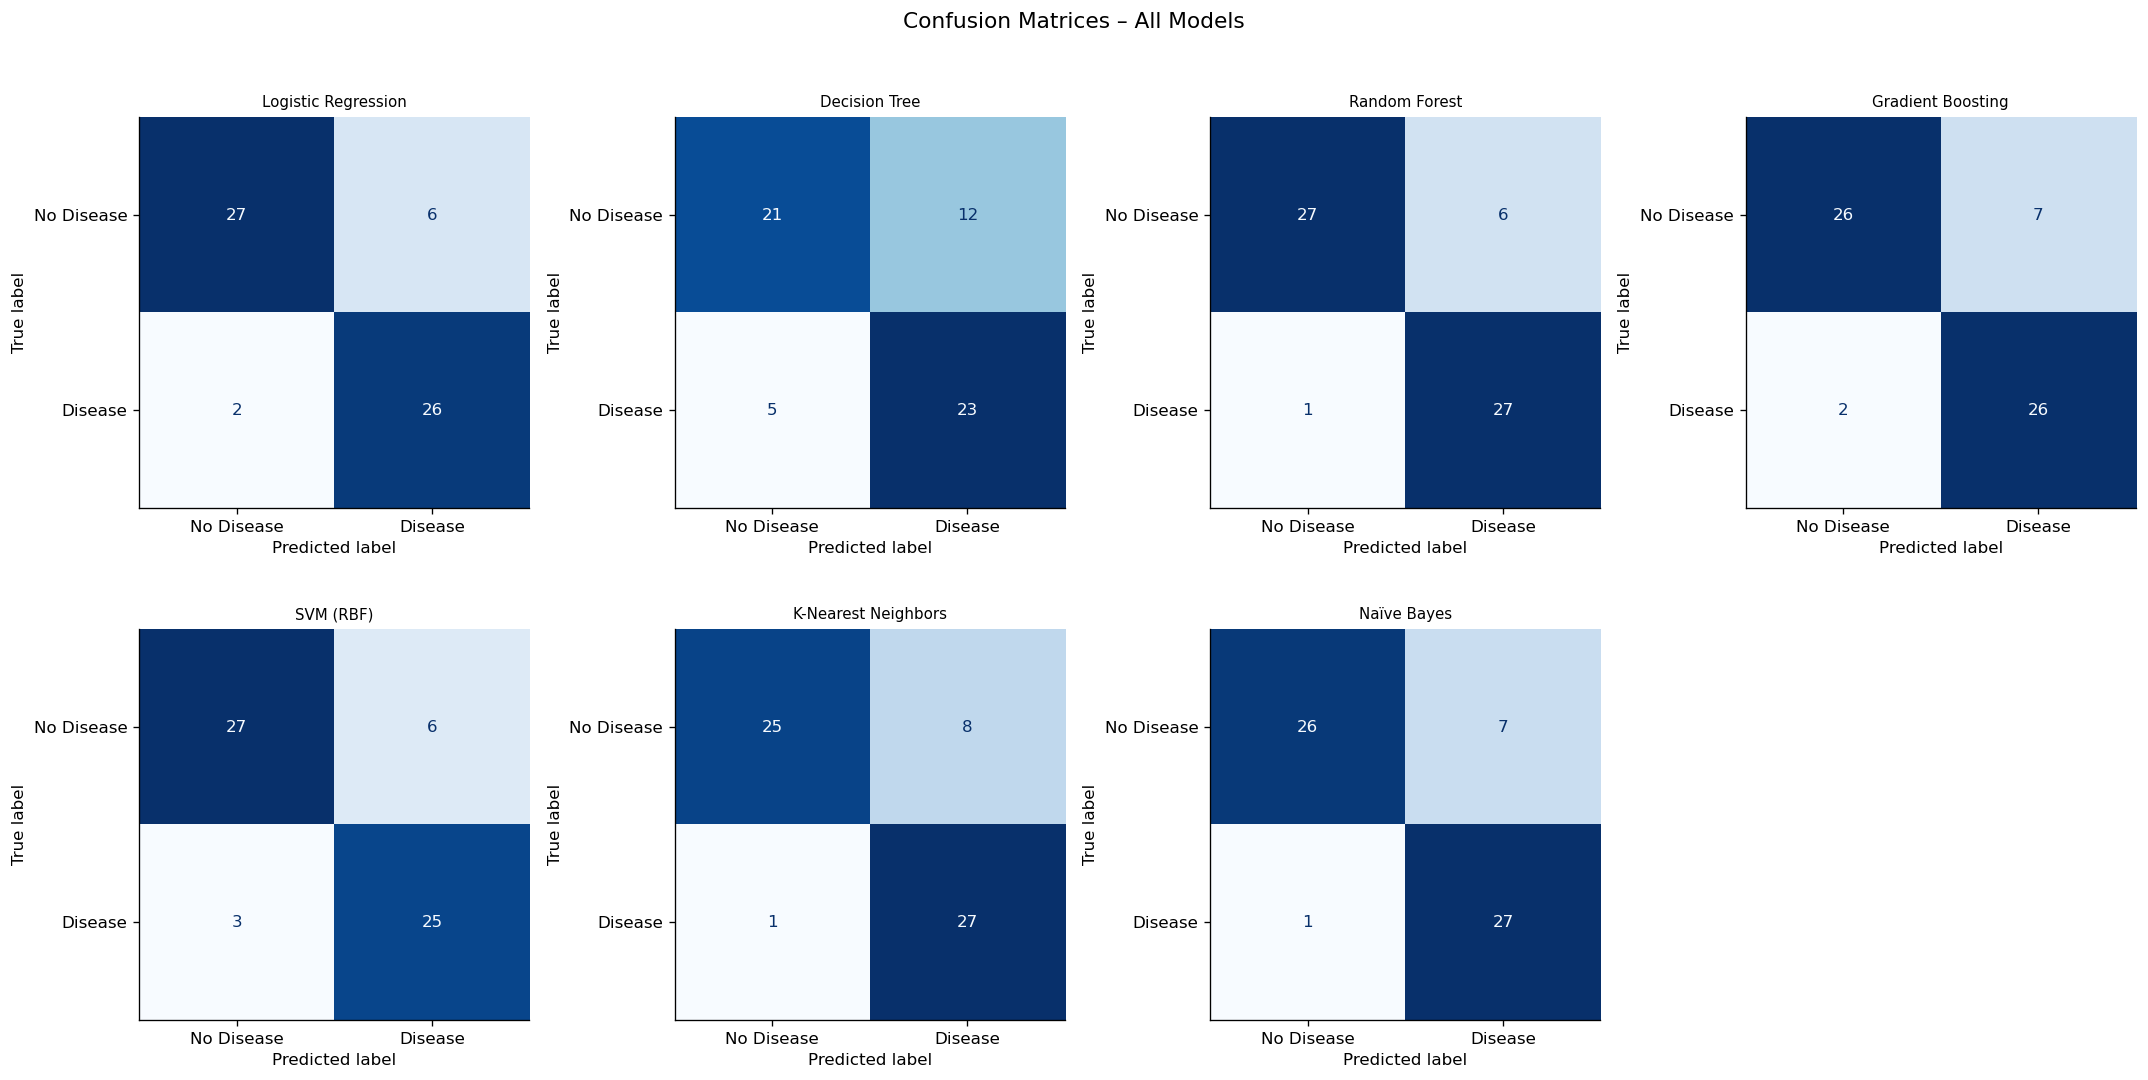

In [13]:
# Confusion matrices – all models in one figure
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, (name, d) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, d["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=9)

for ax in axes[len(results):]:
    ax.set_visible(False)

plt.suptitle("Confusion Matrices – All Models", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches="tight")
plt.show()


## 6. Identify the Best Model  
**5 pt**

### How do we decide which model is "best"?
We rank by **F1-score** because it balances both precision and recall — important in a medical context 
where both false positives (unnecessary stress/tests) and false negatives (missed disease) carry costs.

The full classification report below shows per-class performance:
- **Support** = number of actual cases in the test set for that class
- **Macro avg** = unweighted average across both classes
- **Weighted avg** = average weighted by support (accounts for class imbalance)


In [30]:
best_name = metrics_df["f1"].idxmax()
best = results[best_name]

print(f"Best model (by F1): {best_name}")
print(f"   Accuracy  : {best['accuracy']:.4f}")
print(f"   Precision : {best['precision']:.4f}")
print(f"   Recall    : {best['recall']:.4f}")
print(f"   F1-score  : {best['f1']:.4f}")
print(f"   ROC-AUC   : {best['roc_auc']:.4f}")
print()
print(classification_report(y_test, best["y_pred"],
      target_names=["No Disease", "Disease"]))


Best model (by F1): Random Forest
   Accuracy  : 0.8852
   Precision : 0.8182
   Recall    : 0.9643
   F1-score  : 0.8852
   ROC-AUC   : 0.9513

              precision    recall  f1-score   support

  No Disease       0.96      0.82      0.89        33
     Disease       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



## 7. Fusion / Ensemble Methods  
**10 pt** – Soft Voting ensemble + Stacking meta-learner


### Why use ensemble / fusion methods?
Individual models each have blind spots. **Ensemble methods** combine multiple models so their 
weaknesses cancel out and their strengths reinforce each other — like asking several doctors for 
a second opinion and going with the consensus.

**Soft Voting Ensemble**  
Each of the 4 base models outputs a *probability* that a patient has disease. 
The ensemble averages these probabilities and classifies based on the average. 
This is more nuanced than hard voting (simple majority) because confident predictions carry more weight.

**Stacking Classifier**  
A more sophisticated approach: the predictions of the 3 base models become *input features* for a 
second-level "meta-learner" (Logistic Regression). The meta-learner learns *which base models to trust* 
in which situations. Think of it as a manager who learns from experience which team members are reliable 
for which types of problems.


In [15]:
# ── 7a. Soft Voting Ensemble ─────────────────────────────────────────────
voting_clf = VotingClassifier(
    estimators=[
        ("lr",  LogisticRegression(max_iter=1000, random_state=42)),
        ("rf",  RandomForestClassifier(n_estimators=100, random_state=42)),
        ("gb",  GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ("svm", SVC(probability=True, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=3)),
    ],
    voting="soft"
)

voting_clf.fit(X_train_sc, y_train)
vot_pred = voting_clf.predict(X_test_sc)
vot_prob = voting_clf.predict_proba(X_test_sc)[:, 1]

print("=== Soft Voting Ensemble ===")
print(classification_report(y_test, vot_pred, target_names=["No Disease","Disease"]))
print(f"ROC-AUC: {roc_auc_score(y_test, vot_prob):.4f}")


=== Soft Voting Ensemble ===
              precision    recall  f1-score   support

  No Disease       0.93      0.79      0.85        33
     Disease       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

ROC-AUC: 0.9491


In [16]:
# ── 7b. Stacking Classifier ──────────────────────────────────────────────
estimators = [
    ("lr",  LogisticRegression(max_iter=1000, random_state=42)),
    ("rf",  RandomForestClassifier(n_estimators=100, random_state=42)),
    ("gb",  GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ("knn", KNeighborsClassifier(n_neighbors=3)),
]
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5, passthrough=False
)
stacking_clf.fit(X_train_sc, y_train)
st_pred = stacking_clf.predict(X_test_sc)
st_prob = stacking_clf.predict_proba(X_test_sc)[:, 1]

print("=== Stacking Classifier ===")
print(classification_report(y_test, st_pred, target_names=["No Disease","Disease"]))
print(f"ROC-AUC: {roc_auc_score(y_test, st_prob):.4f}")


=== Stacking Classifier ===
              precision    recall  f1-score   support

  No Disease       0.96      0.76      0.85        33
     Disease       0.77      0.96      0.86        28

    accuracy                           0.85        61
   macro avg       0.87      0.86      0.85        61
weighted avg       0.87      0.85      0.85        61

ROC-AUC: 0.9491


In [17]:
# Compare ensembles vs best individual model
ens_results = {
    "Soft Voting":  {"y_pred": vot_pred, "y_prob": vot_prob},
    "Stacking":     {"y_pred": st_pred,  "y_prob": st_prob},
}

print(f"{'Model':25s} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
print("-"*60)
for n, d in {**{k: results[k] for k in [best_name]}, **ens_results}.items():
    yp  = d["y_pred"]
    ypr = d["y_prob"]
    print(f"{n:25s} {accuracy_score(y_test,yp):7.4f} "
          f"{precision_score(y_test,yp,zero_division=0):7.4f} "
          f"{recall_score(y_test,yp,zero_division=0):7.4f} "
          f"{f1_score(y_test,yp,zero_division=0):7.4f} "
          f"{roc_auc_score(y_test,ypr):7.4f}")


Model                         Acc    Prec     Rec      F1     AUC
------------------------------------------------------------
Random Forest              0.8852  0.8182  0.9643  0.8852  0.9513
Soft Voting                0.8525  0.7879  0.9286  0.8525  0.9491
Stacking                   0.8525  0.7714  0.9643  0.8571  0.9491


## 8. Rigorous Validation – Stratified k-Fold Cross-Validation  
**5 pt**

### Why use k-Fold Cross-Validation instead of a single train-test split?
A single 80/20 split gives only **one estimate** of model performance — which could be lucky or unlucky 
depending on which patients ended up in the test set.

**Stratified 10-Fold CV** solves this:
1. Divide the training data into 10 equal "folds"
2. Train on 9 folds, evaluate on the 1 held-out fold
3. Repeat 10 times, each time using a different fold as the test
4. Report the **mean ± standard deviation** across all 10 runs

A small standard deviation means the model is *consistent* — its performance doesn't depend heavily 
on which specific patients it sees. A large std suggests instability or overfitting.

This gives a much more reliable estimate of how the model will perform on truly new patients.


In [18]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":        DecisionTreeClassifier(random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)":            SVC(probability=True, random_state=42),
    "K-Nearest Neighbors":  KNeighborsClassifier(n_neighbors=3),  
    "Naïve Bayes":          GaussianNB(),                          
    "Soft Voting":          voting_clf,
    "Stacking":             stacking_clf,
}

cv_scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_records = []

for name, mdl in cv_models.items():
    cv_res = cross_validate(mdl, X_train_sc, y_train, cv=skf,
                            scoring=cv_scoring, return_train_score=False)
    row = {"Model": name}
    for metric in cv_scoring:
        vals = cv_res[f"test_{metric}"]
        row[f"{metric}_mean"] = vals.mean()
        row[f"{metric}_std"]  = vals.std()
    cv_records.append(row)

cv_df = pd.DataFrame(cv_records).set_index("Model")
print("10-Fold Stratified CV Results (mean ± std):")
for metric in cv_scoring:
    cv_df[metric] = cv_df.apply(
        lambda r: f"{r[metric+'_mean']:.4f} ± {r[metric+'_std']:.4f}", axis=1)
print(cv_df[cv_scoring].to_string())


10-Fold Stratified CV Results (mean ± std):
                            accuracy        precision           recall               f1          roc_auc
Model                                                                                                   
Logistic Regression  0.8223 ± 0.0544  0.8457 ± 0.0914  0.7667 ± 0.1059  0.7973 ± 0.0602  0.9044 ± 0.0548
Decision Tree        0.7150 ± 0.0783  0.6913 ± 0.0996  0.7205 ± 0.0761  0.7010 ± 0.0682  0.7149 ± 0.0759
Random Forest        0.7937 ± 0.0567  0.8086 ± 0.1023  0.7477 ± 0.0790  0.7700 ± 0.0514  0.8800 ± 0.0473
Gradient Boosting    0.7730 ± 0.0479  0.7877 ± 0.0956  0.7205 ± 0.1037  0.7427 ± 0.0507  0.8660 ± 0.0543
SVM (RBF)            0.8138 ± 0.0389  0.8526 ± 0.0890  0.7386 ± 0.0949  0.7829 ± 0.0475  0.8840 ± 0.0412
K-Nearest Neighbors  0.8137 ± 0.0511  0.8018 ± 0.0725  0.8015 ± 0.0895  0.7971 ± 0.0552  0.8708 ± 0.0504
Naïve Bayes          0.8183 ± 0.0318  0.8323 ± 0.0867  0.7848 ± 0.1267  0.7960 ± 0.0408  0.9023 ± 0.0615
Soft Voting

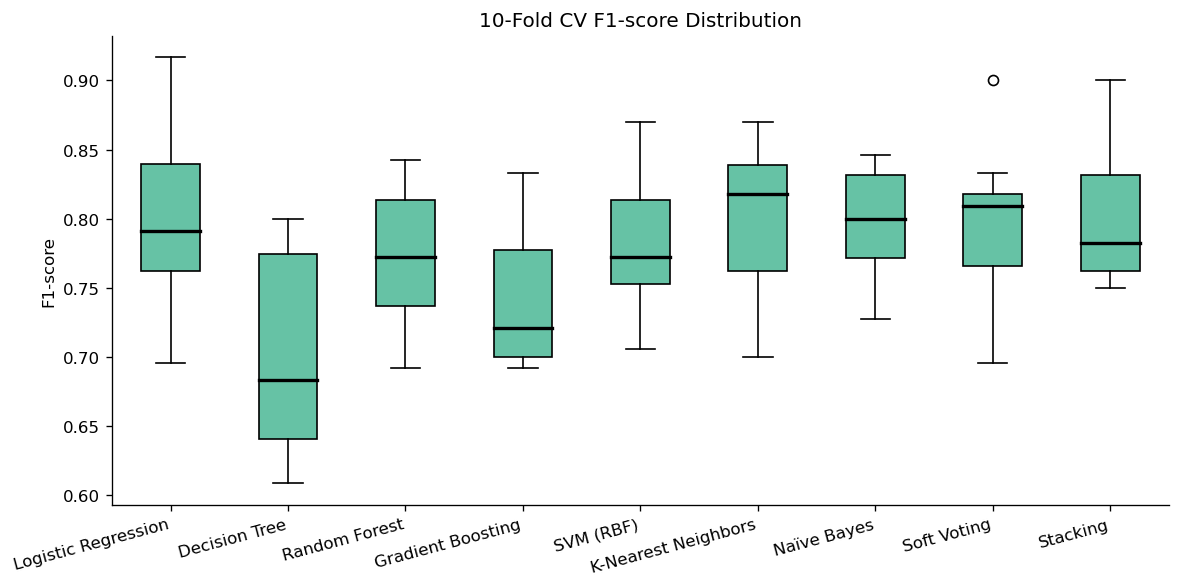

In [19]:
# Visualise CV F1 distributions
fig, ax = plt.subplots(figsize=(10, 5))
cv_f1 = {}
for name, mdl in cv_models.items():
    cv_res = cross_validate(mdl, X_train_sc, y_train, cv=skf, scoring=["f1"])
    cv_f1[name] = cv_res["test_f1"]

ax.boxplot(cv_f1.values(), labels=cv_f1.keys(), patch_artist=True,
           medianprops=dict(color="black", linewidth=2))
ax.set_title("10-Fold CV F1-score Distribution")
ax.set_ylabel("F1-score")
ax.set_xticklabels(cv_f1.keys(), rotation=15, ha="right")
plt.tight_layout()
plt.savefig("cv_boxplot.png", bbox_inches="tight")
plt.show()


## 9. Deeper Analysis  
**10 pt** – ROC-AUC curves, feature importance, limitations


### What do the deeper analysis tools tell us?

**ROC Curve (Receiver Operating Characteristic)**  
Plots the True Positive Rate (recall) against the False Positive Rate at every possible 
classification threshold. A model that is just guessing falls on the diagonal dashed line. 
The further a curve bows toward the top-left corner, the better.  
**AUC (Area Under the Curve)** summarizes this in a single number:  
- AUC = 1.0 = perfect classifier  
- AUC = 0.5 = no better than random  
- AUC > 0.8 = generally considered good for clinical data

**Feature Importance**  
Tells us *which input features the model relied on most*. 
In Random Forest, importance is measured by how much each feature reduces prediction error 
across all trees. High-importance features are the strongest signals in the data — 
a domain expert (cardiologist) can then verify whether these make clinical sense.

**Learning Curve**  
Shows how model performance changes as we add more training data.
- If training score is high but validation score is low = **overfitting** (model memorized training data)
- If both scores are low = **underfitting** (model is too simple)
- If both scores converge at a high value = **good fit**


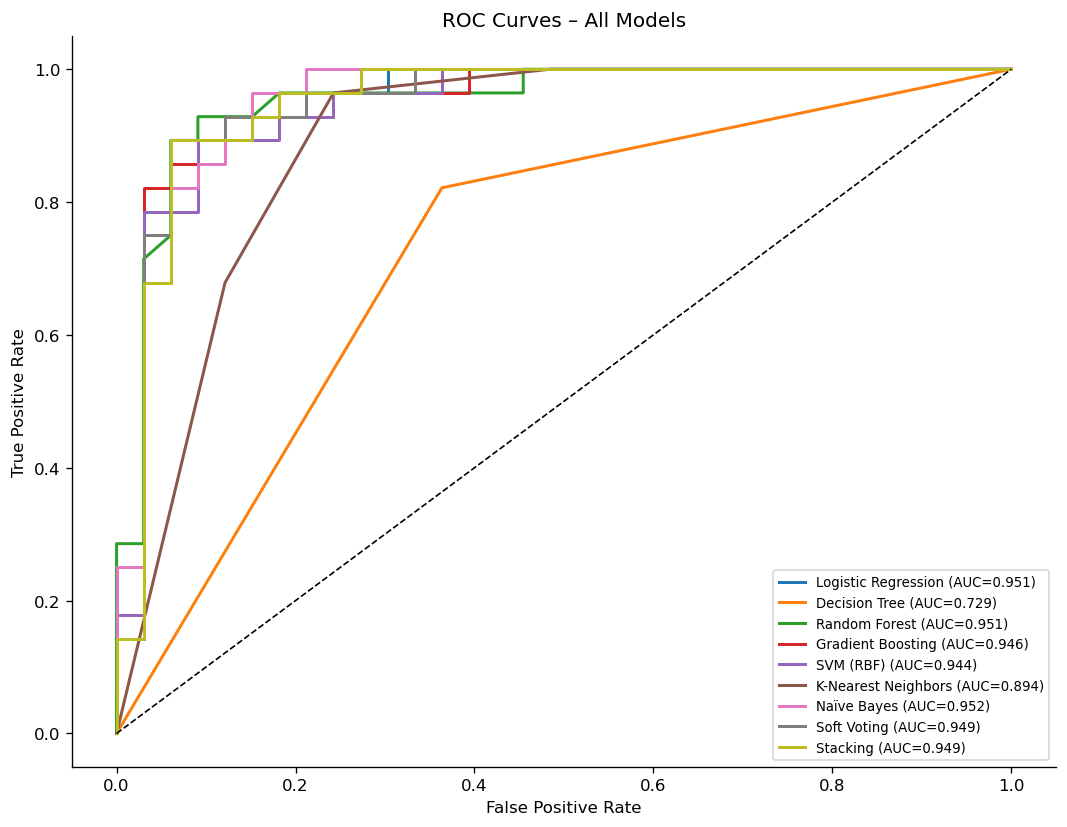

In [20]:
# 9a. ROC Curves 
fig, ax = plt.subplots(figsize=(9, 7))

all_plot = {**results,
            "Soft Voting": {"y_prob": vot_prob},
            "Stacking":    {"y_prob": st_prob}}

colors = plt.cm.tab10.colors
for (name, d), c in zip(all_plot.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, d["y_prob"])
    auc = roc_auc_score(y_test, d["y_prob"])
    ax.plot(fpr, tpr, lw=1.8, color=c, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="ROC Curves – All Models")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("roc_curves.png", bbox_inches="tight")
plt.show()


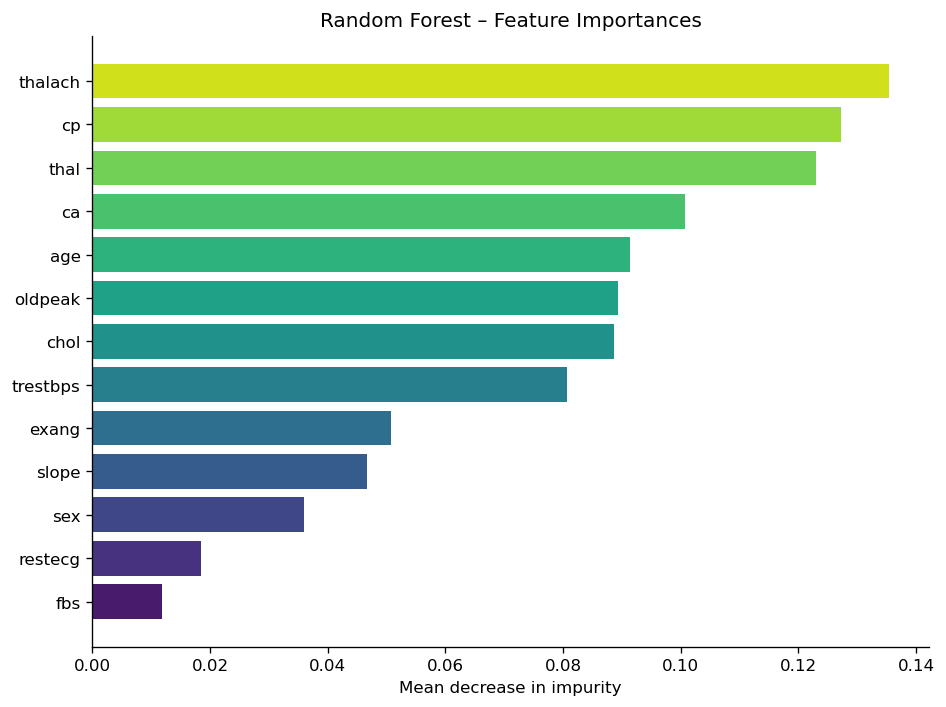


Top 5 Features:
thalach    0.135404
cp         0.127163
thal       0.122940
ca         0.100811
age        0.091327
dtype: float64


In [21]:
# 9b. Feature Importance (Random Forest) ───────────────────────────────
rf_model = results["Random Forest"]["model"]
importances = rf_model.feature_importances_
fi_df = (pd.Series(importances, index=FEATURE_NAMES)
           .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(fi_df.index, fi_df.values,
               color=sns.color_palette("viridis", len(fi_df)))
ax.set_title("Random Forest – Feature Importances")
ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 5 Features:")
print(fi_df.sort_values(ascending=False).head())


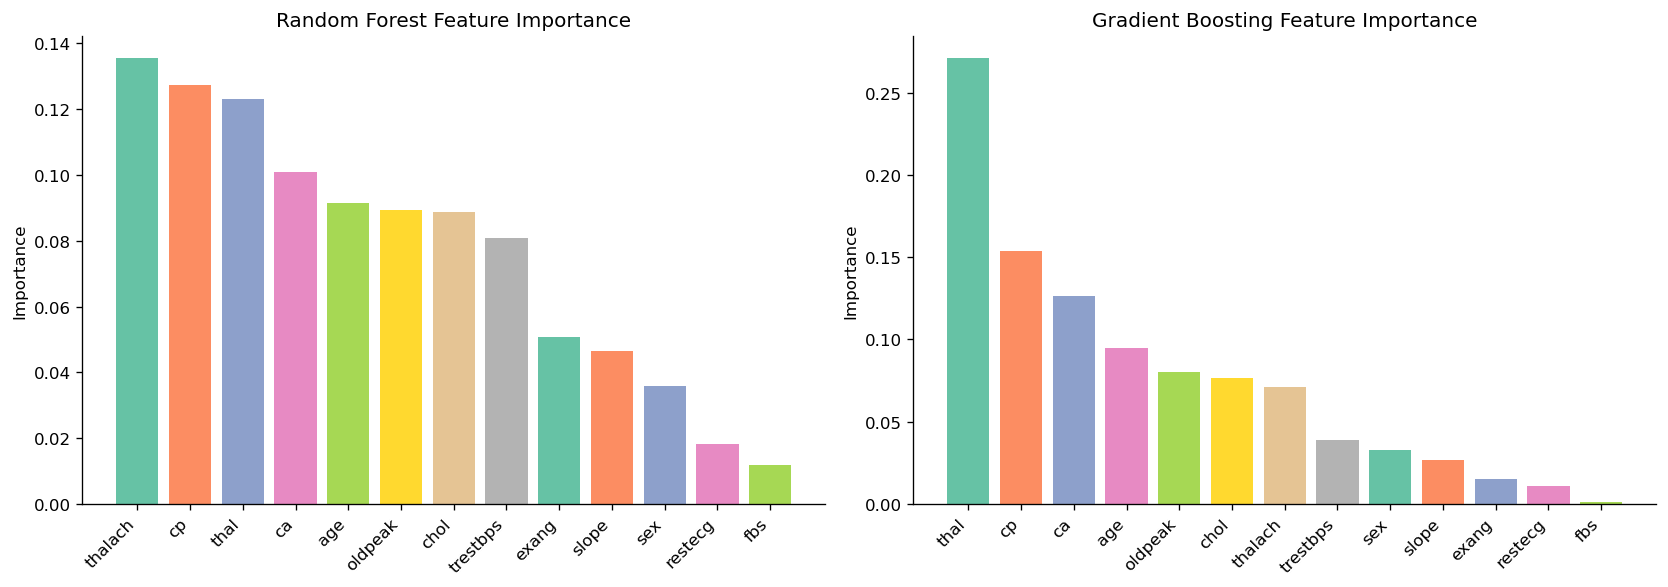

In [22]:
# 9c. Random Forest Gradient Boosting Feature Importance (comparison) 
gb_model = results["Gradient Boosting"]["model"]
gb_fi = pd.Series(gb_model.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, fi) in zip(axes, [("Random Forest", fi_df.sort_values(ascending=False)),
                                    ("Gradient Boosting", gb_fi)]):
    ax.bar(fi.index, fi.values, color=sns.color_palette("Set2", len(fi)))
    ax.set_title(f"{title} Feature Importance")
    ax.set_xticklabels(fi.index, rotation=45, ha="right")
    ax.set_ylabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance_comparison.png", bbox_inches="tight")
plt.show()


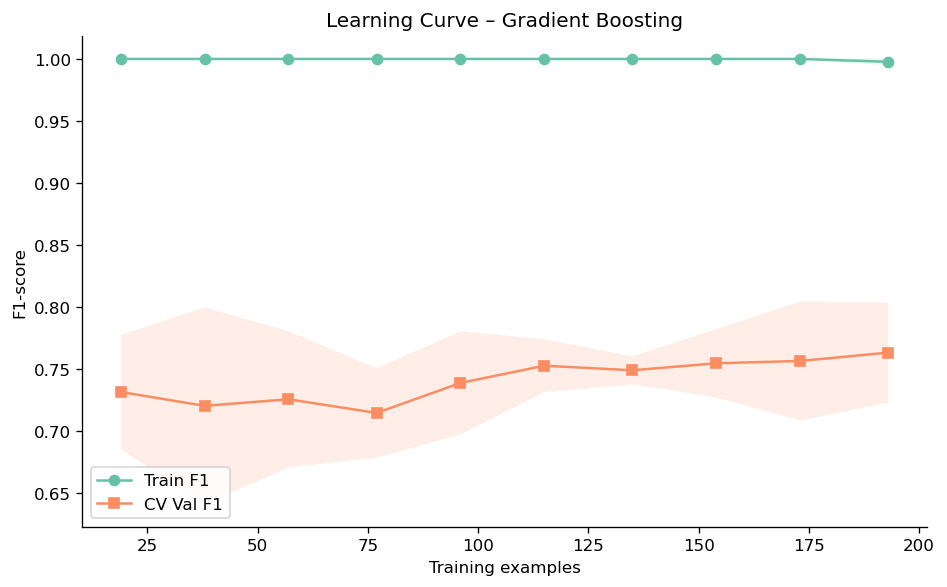

In [23]:
# 9d. Learning Curves for best model 
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    X_train_sc, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="f1", n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train F1")
ax.fill_between(train_sizes,
                train_scores.mean(1)-train_scores.std(1),
                train_scores.mean(1)+train_scores.std(1), alpha=0.15)
ax.plot(train_sizes, val_scores.mean(axis=1), "s-", label="CV Val F1")
ax.fill_between(train_sizes,
                val_scores.mean(1)-val_scores.std(1),
                val_scores.mean(1)+val_scores.std(1), alpha=0.15)
ax.set(title="Learning Curve – Gradient Boosting",
       xlabel="Training examples", ylabel="F1-score")
ax.legend()
plt.tight_layout()
plt.savefig("learning_curve.png", bbox_inches="tight")
plt.show()


KNN Permutation Feature Importance (mean drop in F1 when feature is scrambled):
 feature  importance      std
 thalach    0.050796 0.023782
      ca    0.048791 0.029805
    thal    0.046578 0.031632
     age    0.045461 0.022741
   exang    0.041230 0.031866
 oldpeak    0.038397 0.034163
      cp    0.036765 0.038983
     sex    0.031363 0.023974
   slope    0.014597 0.023780
    chol    0.009601 0.017882
     fbs    0.008934 0.019805
trestbps   -0.004055 0.018324
 restecg   -0.019715 0.015914


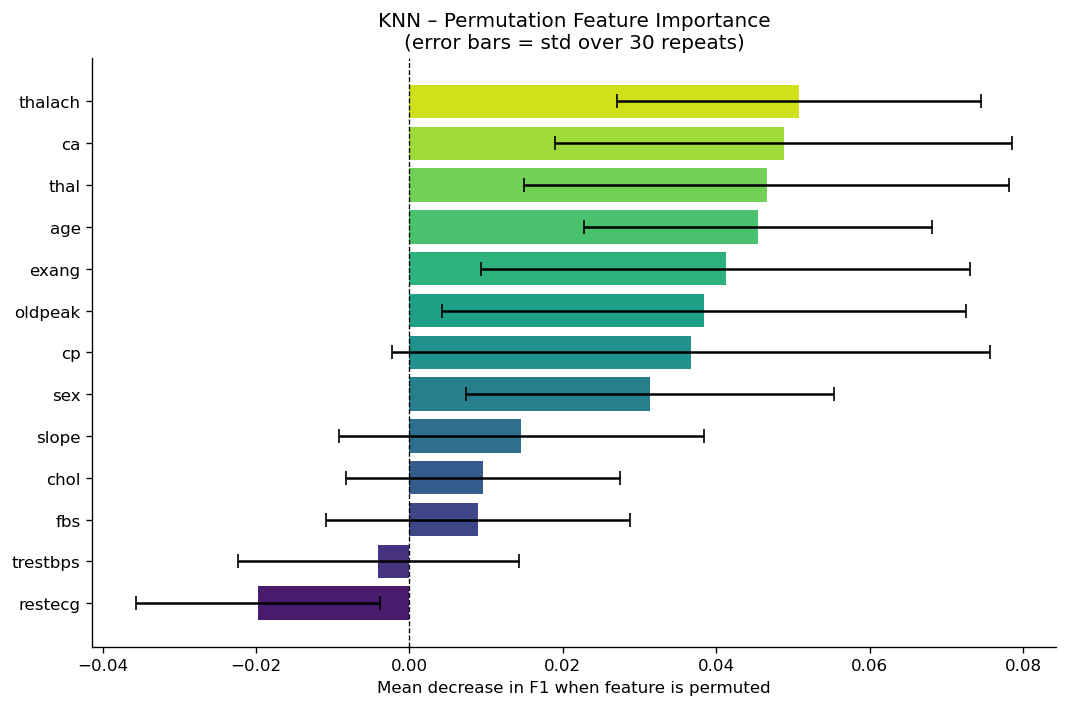

In [24]:
# KNN Permutation Feature Importance
from sklearn.inspection import permutation_importance

knn_model = results["K-Nearest Neighbors"]["model"]

# Run permutation importance on the test set
# n_repeats=30 means each feature is scrambled 30 times for a stable estimate
perm = permutation_importance(
    knn_model,
    X_test_sc,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="f1"
)

# Build a tidy DataFrame from the results
perm_df = pd.DataFrame({
    "feature":    FEATURE_NAMES,
    "importance": perm.importances_mean,  # average drop in F1 over 30 repeats
    "std":        perm.importances_std    # standard deviation across 30 repeats
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("KNN Permutation Feature Importance (mean drop in F1 when feature is scrambled):")
print(perm_df.to_string(index=False))


# ── Standalone KNN Permutation Importance Plot (with error bars) ─────────────
fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    perm_df["feature"][::-1],
    perm_df["importance"][::-1],
    xerr=perm_df["std"][::-1],
    color=sns.color_palette("viridis", len(perm_df)),
    capsize=4
)
ax.set_title("KNN – Permutation Feature Importance\n(error bars = std over 30 repeats)")
ax.set_xlabel("Mean decrease in F1 when feature is permuted")
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.savefig("knn_permutation_importance.png", bbox_inches="tight")
plt.show()

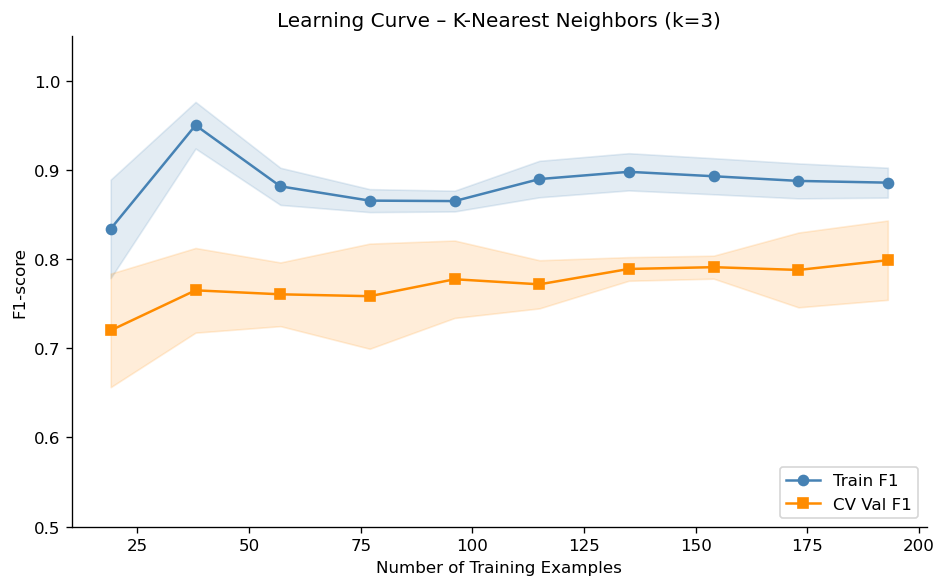

Training sizes:        [ 19  38  57  77  96 115 135 154 173 193]
Mean Train F1:         [0.8338 0.95   0.8815 0.8655 0.865  0.8896 0.8978 0.8928 0.8876 0.8856]
Mean Validation F1:    [0.72   0.7649 0.7605 0.7583 0.7773 0.7717 0.7889 0.7909 0.7878 0.7987]
Train-Val Gap:         [0.1138 0.1851 0.121  0.1071 0.0876 0.118  0.1089 0.1019 0.0998 0.0869]


In [25]:
# Learning Curve – K-Nearest Neighbors 
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    KNeighborsClassifier(n_neighbors=3),
    X_train_sc,
    y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="f1",
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 5))

# Training score line
ax.plot(
    train_sizes,
    train_scores.mean(axis=1),
    "o-",
    color="steelblue",
    label="Train F1"
)
ax.fill_between(
    train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.15,
    color="steelblue"
)

# Validation score line
ax.plot(
    train_sizes,
    val_scores.mean(axis=1),
    "s-",
    color="darkorange",
    label="CV Val F1"
)
ax.fill_between(
    train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.15,
    color="darkorange"
)

ax.set_title("Learning Curve – K-Nearest Neighbors (k=3)")
ax.set_xlabel("Number of Training Examples")
ax.set_ylabel("F1-score")
ax.legend(loc="lower right")
ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig("learning_curve_knn.png", bbox_inches="tight")
plt.show()

# Print the numbers too
print("Training sizes:       ", train_sizes)
print("Mean Train F1:        ", train_scores.mean(axis=1).round(4))
print("Mean Validation F1:   ", val_scores.mean(axis=1).round(4))
print("Train-Val Gap:        ", 
      (train_scores.mean(axis=1) - val_scores.mean(axis=1)).round(4))

Best k: 29
Best CV F1: 0.8197


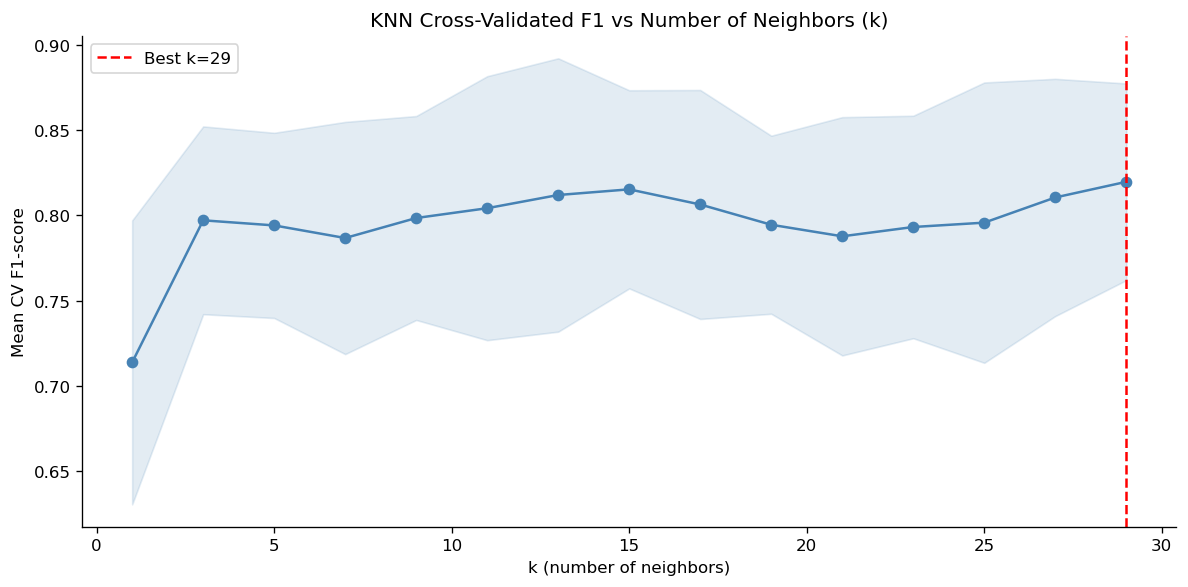

In [26]:
# Find the best number of neighbors for k
from sklearn.model_selection import GridSearchCV

param_grid = {"n_neighbors": range(1, 31, 2)}  # odd numbers 1-29

knn_tuned = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=StratifiedKFold(10, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1
)

knn_tuned.fit(X_train_sc, y_train)

print(f"Best k: {knn_tuned.best_params_['n_neighbors']}")
print(f"Best CV F1: {knn_tuned.best_score_:.4f}")

# Plot F1 vs k
results_df = pd.DataFrame(knn_tuned.cv_results_)
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, 31, 2),
    results_df["mean_test_score"],
    "o-", color="steelblue"
)
plt.fill_between(
    range(1, 31, 2),
    results_df["mean_test_score"] - results_df["std_test_score"],
    results_df["mean_test_score"] + results_df["std_test_score"],
    alpha=0.15, color="steelblue"
)
plt.axvline(
    x=knn_tuned.best_params_["n_neighbors"],
    color="red",
    linestyle="--",
    label=f"Best k={knn_tuned.best_params_['n_neighbors']}"
)
plt.title("KNN Cross-Validated F1 vs Number of Neighbors (k)")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Mean CV F1-score")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# ── Smarter k selection using the 1-SE rule 
results_df = pd.DataFrame(knn_tuned.cv_results_)
results_df["k"] = range(1, 31, 2)

best_score    = results_df["mean_test_score"].max()
best_std      = results_df.loc[
                    results_df["mean_test_score"].idxmax(), 
                    "std_test_score"
                ]
threshold     = best_score - best_std  # one standard error below the best

# Find the smallest k whose mean score is above the threshold
conservative_k = results_df[
    results_df["mean_test_score"] >= threshold
]["k"].min()

print(f"GridSearchCV best k : {knn_tuned.best_params_['n_neighbors']}")
print(f"Best CV F1          : {best_score:.4f}")
print(f"One-SE threshold    : {threshold:.4f}")
print(f"Conservative best k : {conservative_k}")
print()
print("Interpretation: any k above the threshold performs equivalently.")
print(f"We choose k={conservative_k} as it is the simplest model")
print("within one standard error of the best observed performance.")

GridSearchCV best k : 29
Best CV F1          : 0.8197
One-SE threshold    : 0.7619
Conservative best k : 3

Interpretation: any k above the threshold performs equivalently.
We choose k=3 as it is the simplest model
within one standard error of the best observed performance.


## 10. Limitations & Discussion

### Dataset Limitations
1. **Small sample size** (303 rows): susceptible to high variance; results may not generalise.
2. **Single-centre data**: only Cleveland Clinic patients – possible demographic bias.
3. **Missing data** in `ca` and `thal`: median imputation may introduce bias.
4. **Class imbalance** (~54 % positive): borderline; addressed via stratified splits but SMOTE could help further.

### Methodological Limitations
5. **Feature engineering**: raw clinical values used; domain-expert derivation (e.g., heart-rate reserve) may improve performance.
6. **Hyperparameter tuning**: default or lightly tuned settings only; full `GridSearchCV` / `RandomizedSearchCV` would improve scores.

### Ethical Limitations
8. **Fairness**: `sex` is a feature – models may behave differently across groups; fairness auditing not performed.
9. **Interpretability vs. accuracy trade-off**: ensemble methods may be harder to explain to clinicians than Logistic Regression.


## 11. Final Summary

In [29]:
print("=" * 65)
print("          FINAL RESULTS SUMMARY")
print("=" * 65)

summary_rows = []
for name, d in results.items():
    summary_rows.append({
        "Model": name,
        "Accuracy":  round(d["accuracy"], 4),
        "Precision": round(d["precision"], 4),
        "Recall":    round(d["recall"], 4),
        "F1":        round(d["f1"], 4),
        "ROC-AUC":   round(d["roc_auc"], 4),
        "Type": "Individual",
    })

for name, (pred, prob) in [("Soft Voting", (vot_pred, vot_prob)),
                             ("Stacking",    (st_pred,  st_prob))]:
    summary_rows.append({
        "Model": name,
        "Accuracy":  round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, pred, zero_division=0), 4),
        "F1":        round(f1_score(y_test, pred, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, prob), 4),
        "Type": "Ensemble",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model").sort_values("F1", ascending=False)
print(summary_df.to_string())

winner = summary_df["F1"].idxmax()
print(f"\n Overall Best Model: {winner}  (F1 = {summary_df.loc[winner,'F1']:.4f},"
      f"  AUC = {summary_df.loc[winner,'ROC-AUC']:.4f})")


          FINAL RESULTS SUMMARY
                     Accuracy  Precision  Recall      F1  ROC-AUC        Type
Model                                                                        
Random Forest          0.8852     0.8182  0.9643  0.8852   0.9513  Individual
Naïve Bayes            0.8689     0.7941  0.9643  0.8710   0.9524  Individual
Logistic Regression    0.8689     0.8125  0.9286  0.8667   0.9513  Individual
K-Nearest Neighbors    0.8525     0.7714  0.9643  0.8571   0.8939  Individual
Stacking               0.8525     0.7714  0.9643  0.8571   0.9491    Ensemble
Gradient Boosting      0.8525     0.7879  0.9286  0.8525   0.9459  Individual
Soft Voting            0.8525     0.7879  0.9286  0.8525   0.9491    Ensemble
SVM (RBF)              0.8525     0.8065  0.8929  0.8475   0.9437  Individual
Decision Tree          0.7213     0.6571  0.8214  0.7302   0.7289  Individual

 Overall Best Model: Random Forest  (F1 = 0.8852,  AUC = 0.9513)
